In [ ]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [8]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]



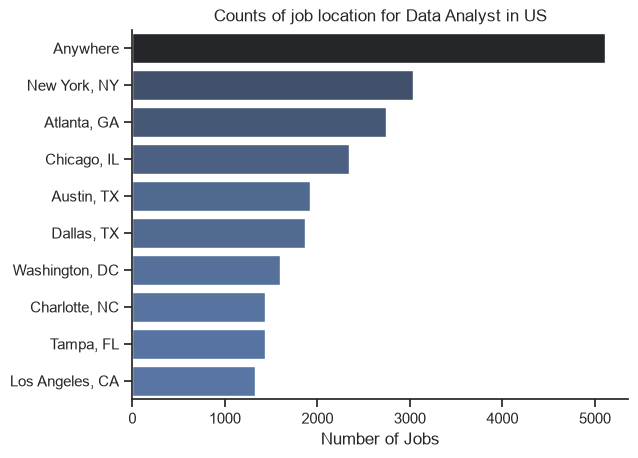

In [26]:
df_plot_1 = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot_1, x='count', y='job_location',hue='count', palette='dark:b_r',legend=False)
sns.despine()
plt.title('Counts of job location for Data Analyst in US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

0 job_work_from_home WFH
1 job_no_degree_mention Degree req
2 job_health_insurance Health_insurance_offered


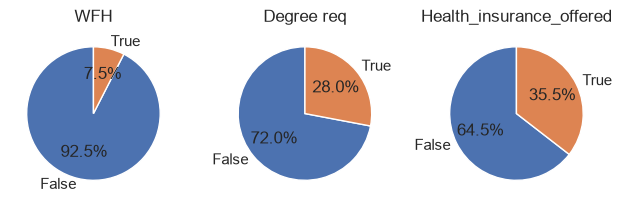

In [27]:
fig, ax = plt.subplots(1,3)

dict_column = {
    'job_work_from_home' : 'WFH',
    'job_no_degree_mention' : 'Degree req',
    'job_health_insurance'  : 'Health_insurance_offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    print(i, column, title)
    df_plot_2 = df_DA_US[column].value_counts()
    df_plot_2.plot(kind='pie', ax=ax[i], title=title, startangle = 90, autopct= '%1.1f%%', labels=[False,True])
    ax[i].set_title(title)

plt.tight_layout()
plt.show()

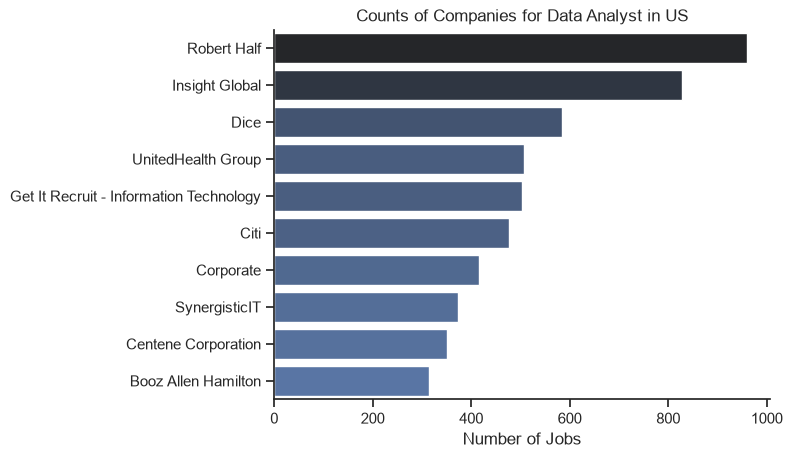

In [29]:
df_plot_3 = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot_3, x='count', y='company_name',hue='count', palette='dark:b_r',legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()